[Step 8 - Chroma vs FAISS head to head]

> **MLCourse - Agentic AI - Vector Stores**
> Stage in the capstone: STORE + RETRIEVE backbone.

## What you will learn

1. Running IDENTICAL chunks through BOTH stores under identical conditions.
2. Comparing top-1 and top-3 results with stable per-chunk ids.
3. Measuring average search latency fairly and plotting it as bars.
4. Turning measurements into a decision guide instead of folklore.

Fair-comparison rules used below: same corpus, same embedder, same k, same
query list, repeated timing loops (single shots are noise). Anything else and
you are comparing your setup mistakes, not the stores.

In [1]:
# ---------------------------------------------------------------------------
# Setup cell (identical in every MLCourse notebook): imports, TRACK walker,
# DATA folder creation, .env loading, matplotlib inline magic - guarded so
# the file also runs as a plain script outside Jupyter.
# ---------------------------------------------------------------------------
from pathlib import Path


def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until a directory named ``target`` shows up."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(
        f"Could not find '{target}' above {start}. "
        "Open this notebook from inside the MLCourse repository."
    )


TRACK = find_track(Path.cwd())       # .../MLCourse/03_agentic_ai
DATA = TRACK / "data"                # one shared data folder for the track
DATA.mkdir(exist_ok=True)            # no-op when it already exists

from dotenv import load_dotenv       # noqa: E402  reads KEY=value files

load_dotenv()                        # .env beside the current directory
load_dotenv(TRACK / ".env")          # .env at the track root

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass                             # magic only exists inside IPython/Jupyter

import matplotlib.pyplot as plt      # noqa: E402

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## Build the shared corpus once

Same recipe as notebooks 01/02 (20k chars, chapter regex, 500/100 splitter)
plus ONE addition: every chunk gets a stable `chunk_id` in its metadata.
Store-internal ids are implementation details that differ between Chroma and
FAISS; our own id makes results directly comparable across both.

In [2]:
import re
import shutil
import time
import pandas as pd
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings

ALICE_URL = "https://www.gutenberg.org/files/11/11-0.txt"
alice_path = DATA / "alice.txt"
if not alice_path.exists():                          # download once, reuse always
    import urllib.request
    urllib.request.urlretrieve(ALICE_URL, alice_path)

RAW = alice_path.read_text(encoding="utf-8-sig")[:20_000]     # speed slice

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", RAW, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(RAW)
    for piece in splitter.split_text(RAW[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1)},
        ))
for idx, doc in enumerate(documents):                # stable cross-store ids
    doc.metadata["chunk_id"] = idx

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2")

print("[corpus] chunks:", len(documents), "| chapters:", len(marks))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[corpus] chunks: 60 | chapters: 2


## Index the SAME documents into BOTH stores

Chroma gets a wiped folder so reruns cannot accumulate duplicates; FAISS is
built fresh in memory each run by design (its persistence was notebook 02's
lesson). One embedder object serves both stores - removing embedder variance
from the experiment entirely.

In [3]:
from langchain_chroma import Chroma                  # official wrapper
from langchain_community.vectorstores import FAISS   # official community wrapper

CHROMA_DIR = DATA / "h2h_chroma"
if CHROMA_DIR.exists():                              # rerun-safe clean slate
    shutil.rmtree(CHROMA_DIR)

chroma_db = Chroma.from_documents(
    documents,
    embedding=embeddings,
    collection_name="alice_h2h",
    persist_directory=str(CHROMA_DIR),
)
faiss_db = FAISS.from_documents(documents, embeddings)  # flat L2, in memory

print("[stores] chroma count:", len(chroma_db.get()["ids"]))
print("[stores] faiss count :", faiss_db.index.ntotal)

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_63612\3805095548.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS   # official community wrapper


[stores] chroma count: 60
[stores] faiss count : 60


## Five identical questions, ids collected from both stores

We log top-1 ids, whether they agree, how many of the top-3 sets overlap, and
keep full top-3 lists for inspection. Expectation: NEAR-IDENTICAL ordering -
both stores scan the same vectors with the same math, so tiny floating-point
differences only ever shuffle near-ties at the ranking boundary.

In [4]:
QUERIES = [
    "Who fell down the rabbit hole?",
    "What made Alice grow very tall?",
    "Why was the pool of tears salty?",
    "How did the animals dry off after swimming?",
    "What does the Duchess do with pepper?",
]

rows = []
for q in QUERIES:
    chroma_ids = [d.metadata["chunk_id"]
                  for d in chroma_db.similarity_search(q, k=3)]
    faiss_ids = [d.metadata["chunk_id"]
                 for d in faiss_db.similarity_search(q, k=3)]
    rows.append({
        "query": q[:32] + "...",
        "chroma_top1": chroma_ids[0],
        "faiss_top1": faiss_ids[0],
        "top1_same": chroma_ids[0] == faiss_ids[0],
        "top3_shared": len(set(chroma_ids) & set(faiss_ids)),
        "_chroma_top3": chroma_ids,              # kept out of the printed table
        "_faiss_top3": faiss_ids,
    })

cmp_df = pd.DataFrame(rows)
pd.set_option("display.width", 140)
print(cmp_df.drop(columns=["_chroma_top3", "_faiss_top3"]).to_string(index=False))

print("\nfull top-3 lists:")
for row in rows:
    print(" Q:", row["query"])
    print("   chroma:", row["_chroma_top3"], "| faiss:", row["_faiss_top3"])

top1_rate = cmp_df["top1_same"].mean()
overlap_avg = cmp_df["top3_shared"].mean()
print("\ntop-1 agreement : %.0f%%" % (top1_rate * 100))
print("avg top-3 overlap: %.1f of 3 chunks" % overlap_avg)
print("Near-identical ordering is EXPECTED - same vectors, same distances.")

                              query  chroma_top1  faiss_top1  top1_same  top3_shared
  Who fell down the rabbit hole?...            4           4       True            3
 What made Alice grow very tall?...           26          26       True            3
Why was the pool of tears salty?...           35          35       True            3
How did the animals dry off afte...           57          57       True            3
What does the Duchess do with pe...           41          41       True            3

full top-3 lists:
 Q: Who fell down the rabbit hole?...
   chroma: [4, 3, 42] | faiss: [4, 3, 42]
 Q: What made Alice grow very tall?...
   chroma: [26, 33, 32] | faiss: [26, 33, 32]
 Q: Why was the pool of tears salty?...
   chroma: [35, 55, 40] | faiss: [35, 55, 40]
 Q: How did the animals dry off afte...
   chroma: [57, 54, 55] | faiss: [57, 54, 55]
 Q: What does the Duchess do with pe...
   chroma: [41, 6, 25] | faiss: [41, 6, 25]

top-1 agreement : 100%
avg top-3 overlap: 3.0 of 

## Timing: repeated loops, then a bar chart

Latency methodology: REPEATS x 5 searches per store, wall-clock split via
time.perf_counter, averaged per call. At ~40 vectors both stores are blazing;
differences you see here are overheads (Chroma's DB layer vs FAISS's leaner
path), and they GROW with corpus size in FAISS's favor.

avg ms per k=3 search: {'chroma': 15.137, 'faiss': 8.561}
totals over 150 calls each: chroma 2.271s | faiss 1.284s


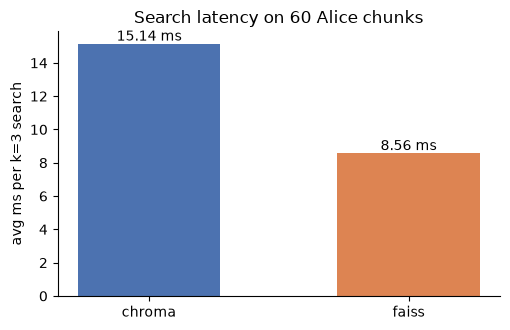

In [5]:
REPEATS = 30
n_calls = REPEATS * len(QUERIES)

t0 = time.perf_counter()
for _ in range(REPEATS):
    for q in QUERIES:
        chroma_db.similarity_search(q, k=3)
chroma_total = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(REPEATS):
    for q in QUERIES:
        faiss_db.similarity_search(q, k=3)
faiss_total = time.perf_counter() - t0

per_call_ms = {
    "chroma": chroma_total / n_calls * 1000,
    "faiss": faiss_total / n_calls * 1000,
}
print("avg ms per k=3 search:",
      {name: round(ms, 3) for name, ms in per_call_ms.items()})
print("totals over %d calls each: chroma %.3fs | faiss %.3fs"
      % (n_calls, chroma_total, faiss_total))

fig, ax = plt.subplots(figsize=(5.2, 3.4))
bars = ax.bar(per_call_ms.keys(), per_call_ms.values(),
              color=["#4c72b0", "#dd8452"], width=0.55)
ax.bar_label(bars, fmt="%.2f ms")
ax.set_ylabel("avg ms per k=3 search")
ax.set_title("Search latency on %d Alice chunks" % len(documents))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Verdict guidance recap

Measurements above are the INPUT; here is the decision rule they support.

In [6]:
print("""
VERDICT GUIDE (recap)
---------------------
tiny-to-medium corpus, want filters + easy persistence ....... chroma
huge corpus, tightest latency, custom index control .......... faiss
metadata filtering central to your queries ................... chroma
already running custom serving infrastructure ................ faiss
learning or prototyping today ................................ either (pick chroma)

Both are server-less libraries running inside your Python process;
both speak the identical LangChain interface shown above, so switching
later costs one constructor line - decide with data, revisit at scale.
""")


VERDICT GUIDE (recap)
---------------------
tiny-to-medium corpus, want filters + easy persistence ....... chroma
huge corpus, tightest latency, custom index control .......... faiss
metadata filtering central to your queries ................... chroma
already running custom serving infrastructure ................ faiss
learning or prototyping today ................................ either (pick chroma)

Both are server-less libraries running inside your Python process;
both speak the identical LangChain interface shown above, so switching
later costs one constructor line - decide with data, revisit at scale.



## Takeaway

- Identical inputs give near-identical rankings: correctness is not the
  differentiator; persistence model, filters, and scale behavior are.
- Compare stores with stable ids, fixed k, and repeated timed loops.

## Summary

We indexed the same chapter-tagged Alice chunks into Chroma and FAISS with a
single shared embedder, ran five identical queries through both, showed
top-1/top-3 agreement in a DataFrame, charted averaged latencies, and closed
with a concrete verdict guide. Module 09 now hides whichever store you pick
behind the retriever interface.